In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load merged data from Phase 1
df = pd.read_csv("tsla_merged.csv", index_col='Date', parse_dates=True)
print(f"Loaded {len(df)} days of data")
print(df.columns)

Loaded 29675 days of data
Index(['tweet_text', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from transformers import pipeline
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textblob
import torch
import os

# Download VADER lexicon (run once)
nltk.download('vader_lexicon', quiet=True)

# Initialize sentiment tools
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0 if torch.cuda.is_available() else -1)
vader = SentimentIntensityAnalyzer()

def get_finbert_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    try:
        result = finbert(text[:512])[0]  # truncate to 512 tokens
        score = result['score'] if result['label'] == 'positive' else -result['score']
        return score
    except:
        return 0.0

def get_vader_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    scores = vader.polarity_scores(text)
    return scores['compound']

def get_textblob_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    return textblob.TextBlob(text).sentiment.polarity

# Compute sentiment scores (this may take time - run on sample first)
print("Calculating sentiment scores...")

df['finbert_score'] = df['tweet_text'].apply(get_finbert_sentiment)
df['vader_score'] = df['tweet_text'].apply(get_vader_sentiment)
df['textblob_score'] = df['tweet_text'].apply(get_textblob_sentiment)

# Compare them
print("\nSentiment Score Statistics:")
print(df[['finbert_score', 'vader_score', 'textblob_score']].describe())
os.makedirs("results", exist_ok=True)
# Save intermediate result
df.to_csv("results/tsla_with_sentiment.csv")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Calculating sentiment scores...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Sentiment Score Statistics:
       finbert_score   vader_score  textblob_score
count   29675.000000  29675.000000    29675.000000
mean       -0.611644      0.151415        0.098310
std         0.560613      0.433512        0.246881
min        -0.976651     -0.993600       -1.000000
25%        -0.912971      0.000000        0.000000
50%        -0.854004      0.000000        0.000000
75%        -0.667453      0.493900        0.220422
max         0.959090      0.987100        1.000000


In [3]:
import pandas as pd
import numpy as np

print("Extracting daily price data...")
daily_price = df[['Open', 'High', 'Low', 'Close', 'Volume']].groupby(df.index).first().sort_index()

print("Calculating technical indicators on daily data (native pandas)...")
daily_price['returns'] = daily_price['Close'].pct_change()
daily_price['log_returns'] = np.log(daily_price['Close'] / daily_price['Close'].shift(1))
daily_price['sma_10'] = daily_price['Close'].rolling(10).mean()
daily_price['sma_20'] = daily_price['Close'].rolling(20).mean()

# Native RSI calculation
delta = daily_price['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
daily_price['rsi'] = 100 - (100 / (1 + rs))

# Native MACD calculation
ema_12 = daily_price['Close'].ewm(span=12, adjust=False).mean()
ema_26 = daily_price['Close'].ewm(span=26, adjust=False).mean()
daily_price['macd'] = ema_12 - ema_26

# Native Bollinger Bands calculation
daily_price['bb_middle'] = daily_price['Close'].rolling(window=20).mean()
std_20 = daily_price['Close'].rolling(window=20).std()
daily_price['bb_upper'] = daily_price['bb_middle'] + 2 * std_20
daily_price['bb_lower'] = daily_price['bb_middle'] - 2 * std_20

daily_price['momentum_10'] = daily_price['Close'] - daily_price['Close'].shift(10)
daily_price['volume_sma_10'] = daily_price['Volume'].rolling(10).mean()

print("Calculating daily forward returns...")
for horizon in [1, 3, 7, 14]:
    daily_price[f'fwd_return_{horizon}'] = daily_price['Close'].shift(-horizon) / daily_price['Close'] - 1

print("Merging daily price features back to tweet-level data...")
df_tweets = df[['tweet_text', 'finbert_score', 'vader_score', 'textblob_score']]
df = df_tweets.join(daily_price, how='inner')

print("Calculating rolling sentiment features...")
df['sentiment_vol_3'] = df['finbert_score'].rolling(3).std()
df['sentiment_ma_5'] = df['finbert_score'].rolling(5).mean()

df.dropna(inplace=True)
print(f"Final dataset shape: {df.shape}")

import os
os.makedirs("results", exist_ok=True)
os.makedirs("notebooks/data/processed", exist_ok=True)
df.to_csv("results/tsla_engineered_final.csv")
df.to_csv("notebooks/data/processed/tsla_engineered_final.csv")
print("Saved dataset to results/ and notebooks/data/processed/")

Extracting daily price data...
Calculating technical indicators on daily data (native pandas)...
Calculating daily forward returns...
Merging daily price features back to tweet-level data...
Calculating rolling sentiment features...
Final dataset shape: (25815, 26)
Saved dataset to results/ and notebooks/data/processed/


<Figure size 1200x600 with 0 Axes>

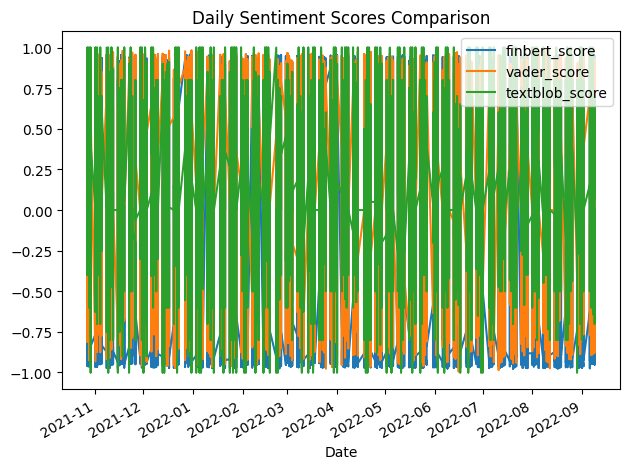


Correlation with next-day return:
finbert_score    -0.010292
vader_score      -0.020885
textblob_score   -0.015315
fwd_return_1      1.000000
Name: fwd_return_1, dtype: float64


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df[['finbert_score', 'vader_score', 'textblob_score']].plot(title="Daily Sentiment Scores Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("results/sentiment_comparison.png")
plt.show()

# Correlation with next day return
print("\nCorrelation with next-day return:")
print(df[['finbert_score', 'vader_score', 'textblob_score', 'fwd_return_1']].corr()['fwd_return_1'])